# Neural Network

In [1]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from utils import *
from logistic_regression import LogisticRegression

## Load Data

In [2]:
def load_data_npy():
    X = np.load("data/X.npy")
    y = np.load("data/y.npy")
    X = X[0:1000]
    y = y[0:1000]
    return X, y

def sigmoid(x):
    return 1. / (1. + np.exp(-x))

X, y = load_data_npy()

print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))
# print ('The first element of X is: ', X[0])

The first element of y is:  0
The last element of y is:  1
The shape of X is: (1000, 400)
The shape of y is: (1000, 1)


## Visualizate the data

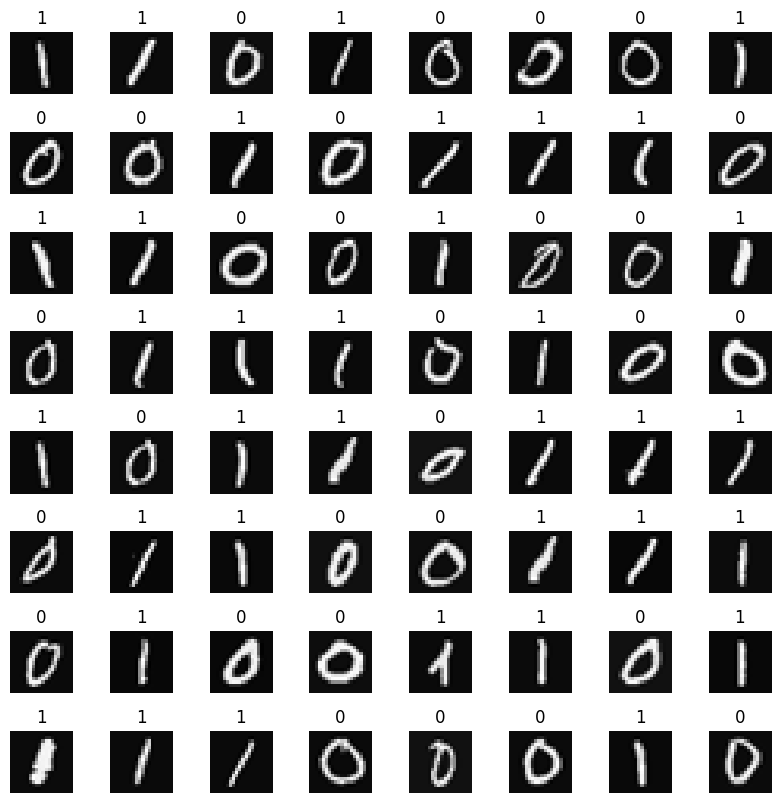

In [3]:
m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1)

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Display the label above the image
    ax.set_title(y[random_index,0])
    ax.set_axis_off()

X shape: (1000, 400)
[Layer  0] w shape: (200, 400), b shape: (200,)
[Layer  1] w shape: (100, 200), b shape: (100,)
[Layer  2] w shape: (10, 100), b shape: (10,)
[Layer  3] w shape: (2, 10), b shape: (2,)


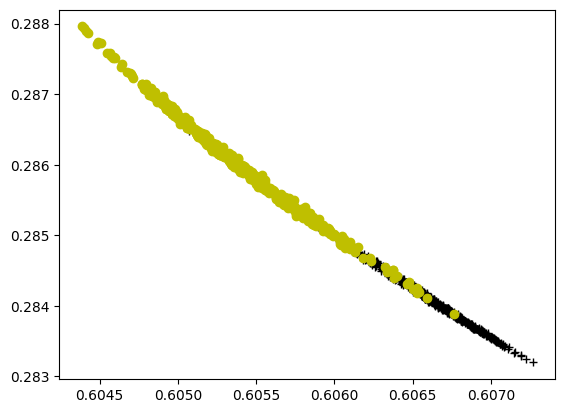

In [34]:
from abc import abstractmethod
from typing import Tuple

class NerveCellActivation:
    def __init__(self):
        pass

    @abstractmethod
    def forward(self, X: NDArray, w: NDArray, b: float):
        pass

class SigmoidActivation(NerveCellActivation):
    def sigmoid(self, z: float) -> float:
        g = 1 / (1 + np.exp(-z))
        return g

    def forward(self, X: NDArray, w: NDArray, b: float) -> float:
        z = np.dot(w, X) + b
        return self.sigmoid(z)

class NeuralLayer:
    def __init__(self, units: int, activation: NerveCellActivation):
        self.units = units
        self.activation = activation
        self.w = np.array([])
        self.b = np.array([])
    
    def init_weights(self, m: int):
        self.w = 0.05 * (np.random.randn(self.units, m) - 0.5)
        self.b = np.random.randn(self.units).T
    
    def weights(self) -> Tuple[NDArray, NDArray]:
        return self.w, self.b

    def set_weights(self, w: NDArray, b: NDArray):
        self.w = w
        self.b = b
    
    def forward(self, X: NDArray) -> NDArray:
        
        m = X.shape[0]
        if self.b.size == 0 or self.w.size == 0:
            self.init_weights(m)

        a = np.zeros(self.units)
        for i in range(self.units):
            a[i] = self.activation.forward(X, self.w[i], self.b[i])

        return a

class NeuralNetwork:
    def __init__(self, X: NDArray, y: NDArray=None):
        self.X = X
        self.y = y
        self.m_in = X.shape[0]
        self.layers = []
    
    def add_layer(self, layer: NeuralLayer):
        self.layers.append(layer)
    
    def weights(self) -> Tuple[NDArray, NDArray]:
        w = []
        b = []
        for layer in self.layers:
            w_layer, b_layer = layer.weights()
            w.append(w_layer)
            b.append(b_layer)
        return w, b
    
    def fit(self) -> NDArray:
        p_hat = np.random.rand(self.m_in, self.layers[-1].units)
        for i in range(self.m_in):
            a = self.X[i]
            for layer in self.layers:
                a = layer.forward(a)
            p_hat[i] = a
        
        return p_hat

def test_neural_network():
    x_tst = 0.1*np.arange(1,3,1).reshape(2,1)  # (1 examples, 2 features)
    W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
    b_tst = 0.1*np.arange(1,4,1).reshape(3,)  # (3 features)
    print(f'x_tst shape: {x_tst.shape}, W_tst shape: {W_tst.shape}, b_tst shape: {b_tst.shape}')
    print(f'{x_tst.T}, {W_tst.T}, {b_tst}')
    nn = NeuralNetwork(x_tst.T)
    layer = NeuralLayer(3, SigmoidActivation())
    layer.set_weights(W_tst.T, b_tst)
    nn.add_layer(layer)
    print(nn.fit())

# test_neural_network()
print(f'X shape: {X.shape}')
nn = NeuralNetwork(X, y)
nn.add_layer(NeuralLayer(200, SigmoidActivation()))
nn.add_layer(NeuralLayer(100, SigmoidActivation()))
nn.add_layer(NeuralLayer(10, SigmoidActivation()))
nn.add_layer(NeuralLayer(2, SigmoidActivation()))
p_hat = nn.fit()

w_arr, b_arr = nn.weights()
for i in range(len(w_arr)):
    print(f'[Layer {i:2d}] w shape: {w_arr[i].shape}, b shape: {b_arr[i].shape}')

# m = p_hat.shape[0]
# for i in range(20):
#     idx = np.random.randint(m)
#     print(f'[{idx:8d}] {y[idx]} {p_hat[idx]}')

def plot_data(X, y, pos_label="y=1", neg_label="y=0"):
    positive = y == 1
    negative = y == 0
    
    # Plot examples
    plt.plot(X[positive, 0], X[positive, 1], 'k+', label=pos_label)
    plt.plot(X[negative, 0], X[negative, 1], 'yo', label=neg_label)


plot_data(p_hat, y[:,0], pos_label="y=1", neg_label="y=0")

